In [1]:
import pandas as pd
import numpy as np
from read_ebas_merged_STN import ebas_nc_to_timetable
from read_betsy_2026 import read_betsy_2026
from change_point_analysis_Def import change_point_analysis_Def
from make_table_breakpoints import make_table_breakpoints
from compute_SSA_D import compute_SSA_D
from compute_exp_D import compute_exp_D
from compute_exp_SSA import compute_exp_ssa
from all_trend_STN import all_trend_STN
from plot_10y_in_two import plot_10y_in_two
from plotFig_var import plotFig_var

df_rd = read_betsy_2026("C:/github_trend/raw_data/NOTO_JPN_abs.csv",'NOTO')
df_rd.drop(columns='time JST (UTC +9:00)',inplace=True)
df_rd = df_rd.rename(columns={'BaR0': 'BaR2_A'})

names_ae = [c for c in df_rd.columns if c.startswith("Ba")]

Read completed: 137793 rows x 3 variables
NaN values: 138751 (33.6%)
Period: 2010-06-17 07:00:00 -> 2026-03-17 06:00:00


In [2]:
attrs = {}

with open("C:/github_trend/raw_data/noto_data_README.txt", encoding="utf-8") as f:
    for line in f:
        if "\t" not in line:
            continue

        key, value = [x.strip() for x in line.split("\t", 1)]
        attrs[key] = value

def get_attr_contains(attrs, text):
    text = text.lower()

    for key, value in attrs.items():
        if text in key.lower():
            return value

    return None

df_st = {"name": (get_attr_contains(attrs, "gaw_id")
        or get_attr_contains(attrs, "station name")),
    "lat": get_attr_contains(attrs, "latitude"),
    "lon": get_attr_contains(attrs, "longitude"),
    "alt": get_attr_contains(attrs, "altitude"),
    "env": get_attr_contains(attrs, "station setting"),
    "footp": get_attr_contains(attrs, "station land use"),}

### Plots

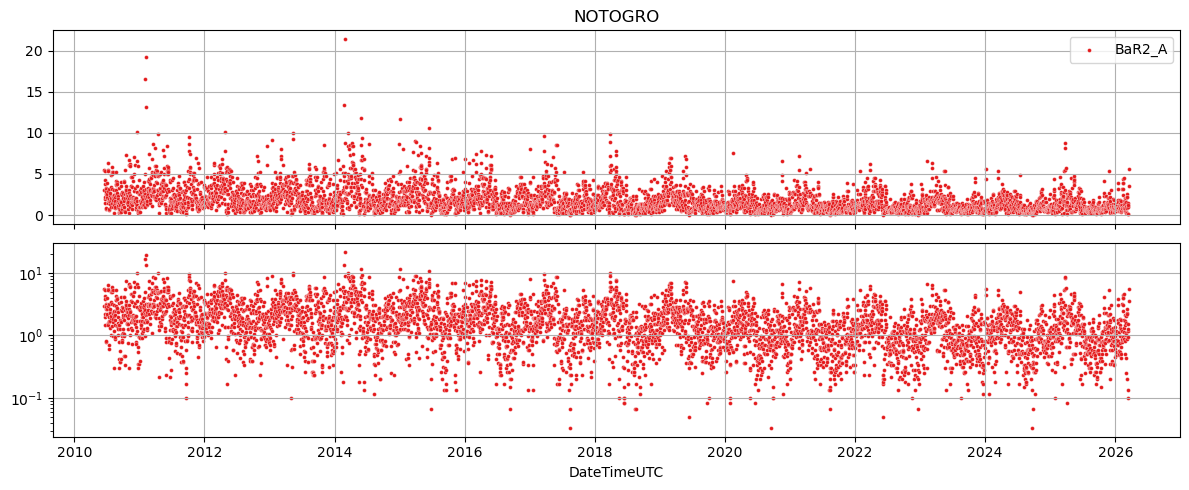

In [3]:
plotFig_var(df_rd,df_st,names_ae,'')

### Break Point detection

c:\Users\ord1867\Desktop\Jordi\PhD\IPCC\LMS_residue.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[param].replace([-np.inf, np.inf], np.nan, inplace=True)


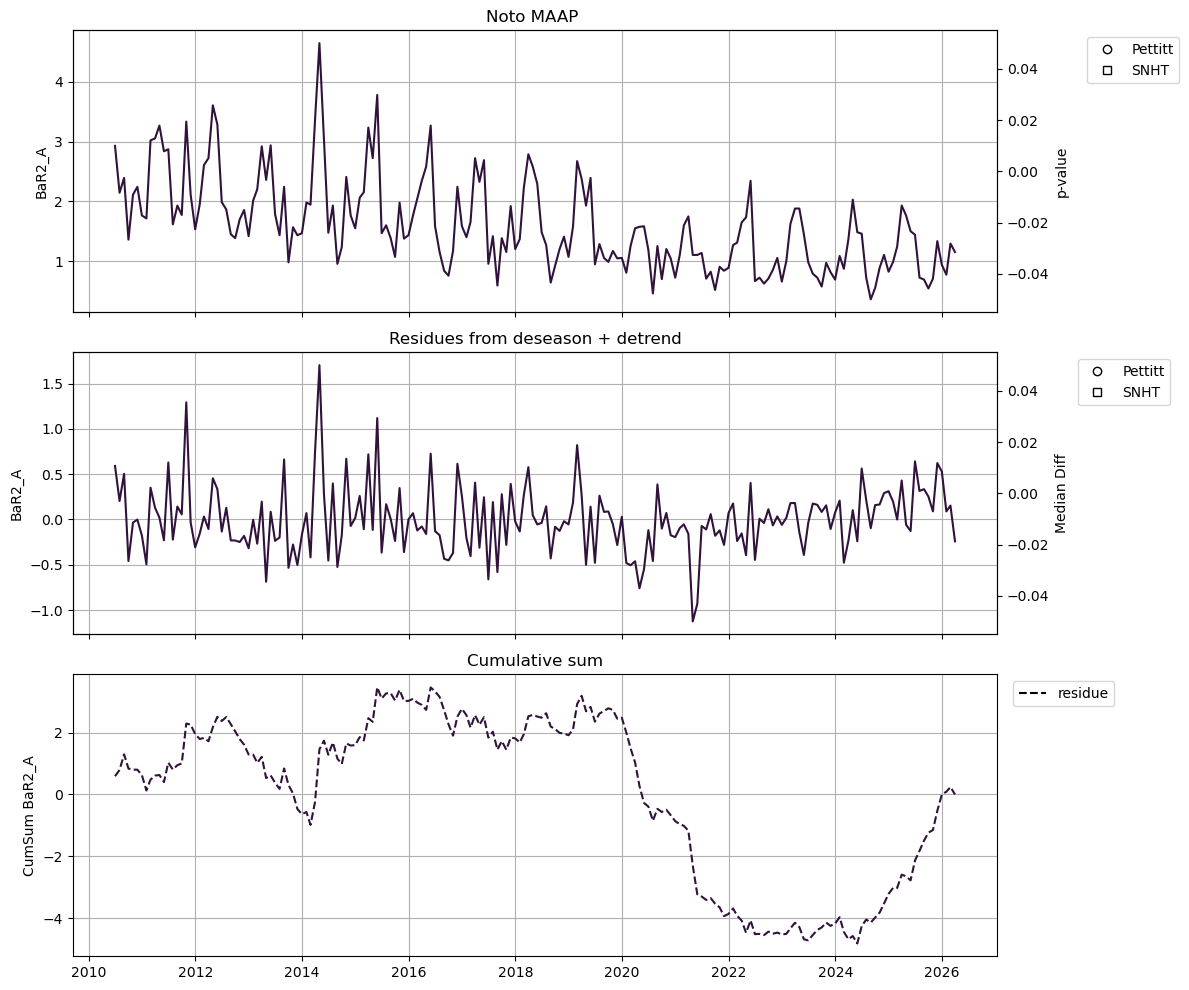

KeyError: 'Break_point'

In [5]:
break_df_abs = change_point_analysis_Def(df_rd,names_ae[:],0.05,'Noto','MAAP')
T_df_abs = make_table_breakpoints(break_df_abs)

### calculs

In [3]:
df_tr= df_rd.copy()

In [7]:
df_result_MK, df_result_LMSlog, df_result_LMSlin = all_trend_STN(df_tr, df_st)

c:\Users\ord1867\anaconda3\Lib\site-packages\mannkendall\mk_main.py:371: UserWarning: The trends for the temporal aggregation are not homogenous.
  warnings.warn('The trends for the temporal aggregation are not homogenous.')
c:\Users\ord1867\anaconda3\Lib\site-packages\mannkendall\mk_main.py:371: UserWarning: The trends for the temporal aggregation are not homogenous.
  warnings.warn('The trends for the temporal aggregation are not homogenous.')
c:\Users\ord1867\anaconda3\Lib\site-packages\mannkendall\mk_main.py:371: UserWarning: The trends for the temporal aggregation are not homogenous.
  warnings.warn('The trends for the temporal aggregation are not homogenous.')
c:\Users\ord1867\anaconda3\Lib\site-packages\mannkendall\mk_main.py:371: UserWarning: The trends for the temporal aggregation are not homogenous.
  warnings.warn('The trends for the temporal aggregation are not homogenous.')
c:\Users\ord1867\anaconda3\Lib\site-packages\mannkendall\mk_main.py:371: UserWarning: The trends for

In [8]:
plot_10y_in_two(df_result_MK, df_st, 'y')

(<Figure size 1000x1200 with 4 Axes>, <Figure size 1000x1200 with 4 Axes>)

In [9]:
df_result_MK.to_csv("C:/github_trend/result/NOTOGRO/NOTO_res_MK.txt", index=False)
df_result_LMSlog.to_csv("C:/github_trend/result/NOTOGRO/NOTO_res_LMSlog.txt", index=False)
df_result_LMSlin.to_csv("C:/github_trend/result/NOTOGRO/NOTO_res_LMSlin.txt", index=False)

### Save NetCDF

In [5]:
ds=df_tr.to_xarray()

for k, v in df_st.items():
    ds.attrs[k] = v
ds.to_netcdf("C:/github_trend/result/NOTOGRO/NOTO.nc")